In [ ]:
from pathlib import Path

NOTEBOOK_DIR = Path().resolve()
BASE_DIR = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
DATA_DIR = BASE_DIR / 'data'
SQL_DIR = BASE_DIR / 'sql'
SRC_DIR = BASE_DIR / 'src'

SQL_DIR.mkdir(exist_ok=True)
SRC_DIR.mkdir(exist_ok=True)

TRANSACTIONS_PATH = DATA_DIR / 'transactions.csv'
CATEGORIES_PATH = DATA_DIR / 'categories.json'
GOLD_SET_PATH = DATA_DIR / 'gold_set.csv'
DB_PATH = BASE_DIR / 'transactions.db'

print(f"Проект: {BASE_DIR}")
print(f"transactions.csv: {TRANSACTIONS_PATH.exists()}")
print(f"categories.json:  {CATEGORIES_PATH.exists()}")
print(f"gold_set.csv:     {GOLD_SET_PATH.exists()}")

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных
df = pd.read_csv('../data/transactions.csv')

print("Размер датасета:", df.shape)
print("\nПервые 5 строк:")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '../data/transactions.csv'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных
df = pd.read_csv(TRANSACTIONS_PATH)

print("Размер датасета:", df.shape)
print("\nПервые 5 строк:")
df.head()

Размер датасета: (80800, 6)

Первые 5 строк:


,sender_id,receiver_id,date,amount_kzt,description,doc_type
0,341113577953,421128527724,2024-10-05,18579.93,"Поставка канцелярских товаров (бумага А4, ручк...",INVOICE
1,950908633188,821120551797,2025-07-29,1706226.33,Поставка медикаментов по списку,INVOICE
2,500817613929,830425668259,2025/05/17,286266.87,"СИЗ: перчатки, очки, респираторы",INVOICE
3,110824699080,220312376061,2024-02-08,996569.04,Грузоперевозка щебня по г. Алматы,INVOICE
4,910816595223,110910187697,20/10/2024,120351.41,ГСМ за февраль 2025,INVOICE


In [3]:
# Базовая информация о датасете
print("=" * 50)
print("ОБЩАЯ ИНФОРМАЦИЯ")
print("=" * 50)
print(f"Строк: {df.shape[0]:,}")
print(f"Столбцов: {df.shape[1]}")
print(f"\nТипы данных:")
print(df.dtypes)
print(f"\nПропуски:")
print(df.isnull().sum())
print(f"\nУникальные отправители: {df['sender_id'].nunique():,}")
print(f"Уникальные получатели: {df['receiver_id'].nunique():,}")
print(f"Уникальные контрагенты всего: {pd.concat([df['sender_id'], df['receiver_id']]).nunique():,}")
print(f"\nТипы документов:")
print(df['doc_type'].value_counts())

ОБЩАЯ ИНФОРМАЦИЯ
Строк: 80,800
Столбцов: 6

Типы данных:
sender_id          str
receiver_id        str
date               str
amount_kzt     float64
description        str
doc_type           str
dtype: object

Пропуски:
sender_id        0
receiver_id      0
date             0
amount_kzt       0
description    847
doc_type         0
dtype: int64

Уникальные отправители: 6,140
Уникальные получатели: 6,099
Уникальные контрагенты всего: 7,215

Типы документов:
doc_type
INVOICE    48530
WAYBILL    16269
ACT        16001
Name: count, dtype: int64


In [4]:
# Период и распределение сумм
print("=" * 50)
print("ПЕРИОД И СУММЫ")
print("=" * 50)

# Нормализация дат для анализа периода
df['date_parsed'] = pd.to_datetime(df['date'], dayfirst=False, errors='coerce')
# Попробуем разные форматы для непарсенных
mask = df['date_parsed'].isna()
df.loc[mask, 'date_parsed'] = pd.to_datetime(df.loc[mask, 'date'], format='%d/%m/%Y', errors='coerce')

print(f"Период: с {df['date_parsed'].min()} по {df['date_parsed'].max()}")
print(f"Непарсенных дат: {df['date_parsed'].isna().sum()}")
print(f"\nСтатистика по суммам (тыс. KZT):")
print((df['amount_kzt'] / 1000).describe().round(1))
print(f"\nМаксимальная транзакция: {df['amount_kzt'].max():,.0f} KZT")
print(f"Минимальная транзакция: {df['amount_kzt'].min():,.0f} KZT")
print(f"Медиана: {df['amount_kzt'].median():,.0f} KZT")

ПЕРИОД И СУММЫ
Период: с 2024-01-01 00:00:00 по 2026-04-30 00:00:00
Непарсенных дат: 34566

Статистика по суммам (тыс. KZT):
count    80800.0
mean      2054.1
std       3633.8
min     -14933.9
25%         46.1
50%        324.1
75%       2189.5
max      14998.6
Name: amount_kzt, dtype: float64

Максимальная транзакция: 14,998,616 KZT
Минимальная транзакция: -14,933,932 KZT
Медиана: 324,097 KZT


FileNotFoundError: [Errno 2] No such file or directory: 'A:/da_project/notebooks/charts_eda.png'

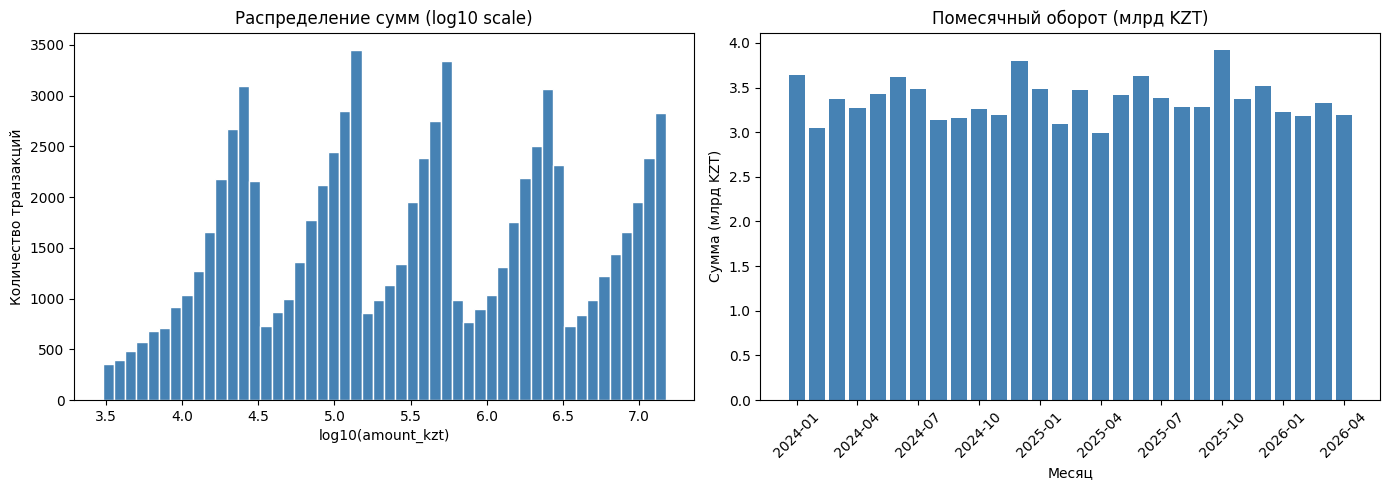

In [5]:
# Визуализация распределения сумм (log-scale)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Только положительные суммы для log-scale
pos = df[df['amount_kzt'] > 0]['amount_kzt']

axes[0].hist(np.log10(pos), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Распределение сумм (log10 scale)')
axes[0].set_xlabel('log10(amount_kzt)')
axes[0].set_ylabel('Количество транзакций')

# Помесячная динамика
monthly = df.dropna(subset=['date_parsed'])
monthly = monthly.groupby(monthly['date_parsed'].dt.to_period('M'))['amount_kzt'].sum() / 1e9

axes[1].bar(range(len(monthly)), monthly.values, color='steelblue')
axes[1].set_title('Помесячный оборот (млрд KZT)')
axes[1].set_xlabel('Месяц')
axes[1].set_ylabel('Сумма (млрд KZT)')
axes[1].set_xticks(range(0, len(monthly), 3))
axes[1].set_xticklabels([str(m) for m in monthly.index[::3]], rotation=45)

plt.tight_layout()
plt.savefig(BASE_DIR / 'notebooks' / 'charts_eda.png', dpi=100)
plt.show()
print("Графики сохранены!")

In [6]:
# Топ-20 контрагентов по обороту
print("=" * 50)
print("ТОП-20 ОТПРАВИТЕЛЕЙ по исходящим")
print("=" * 50)
top_senders = df.groupby('sender_id')['amount_kzt'].sum().sort_values(ascending=False).head(20)
print(top_senders.to_string())

print("\n" + "=" * 50)
print("ТОП-20 ПОЛУЧАТЕЛЕЙ по входящим")
print("=" * 50)
top_receivers = df.groupby('receiver_id')['amount_kzt'].sum().sort_values(ascending=False).head(20)
print(top_receivers.to_string())

print("\n" + "=" * 50)
print("АНОМАЛИИ")
print("=" * 50)
print(f"1. Отрицательные суммы: {(df['amount_kzt'] < 0).sum()} транзакций")
print(f"   Пример: {df[df['amount_kzt'] < 0]['amount_kzt'].min():,.0f} KZT")
print(f"\n2. Пропуски в описании: {df['description'].isna().sum()} строк")
print(f"\n3. Некорректные даты (не парсятся): {df['date_parsed'].isna().sum()} строк")
print(f"   Примеры форматов: {df[df['date_parsed'].isna()]['date'].head(5).tolist()}")

ТОП-20 ОТПРАВИТЕЛЕЙ по исходящим
sender_id
720221554469    7.554451e+08
580811600403    7.445998e+08
310909691346    7.187724e+08
170915651329    7.069924e+08
181226594058    7.033694e+08
140512557513    6.866489e+08
401110643824    6.791805e+08
570328465547    6.405617e+08
941101594315    6.364129e+08
460614400792    6.136171e+08
970913552723    6.118457e+08
270122476708    6.116453e+08
371002684702    5.981690e+08
750125644155    5.935096e+08
861218496740    5.875824e+08
100925580902    5.873830e+08
450815601992    5.725905e+08
181120401530    5.718899e+08
280812467978    5.665917e+08
641104654277    5.482331e+08

ТОП-20 ПОЛУЧАТЕЛЕЙ по входящим
receiver_id
850603506938    3.733961e+08
711020691210    3.494212e+08
551211641020    3.460529e+08
410517502025    3.351119e+08
730424495604    3.230030e+08
121125400846    3.086955e+08
850623490114    3.056108e+08
731211426100    2.842297e+08
990508519961    2.741360e+08
861228440096    2.610135e+08
791108595547    2.609540e+08
740201661314  

In [7]:
# Итоговые выводы EDA
print("=" * 50)
print("ВЫВОДЫ EDA")
print("=" * 50)
print(f"""
1. РАЗМЕР: 80,800 транзакций, 6 полей, период 2024-01 — 2026-04

2. КОНТРАГЕНТЫ: 
   - Уникальных отправителей: 6,140
   - Уникальных получателей: 6,099
   - Всего уникальных: 7,215
   - Топ отправитель (720221554469): 755 млн KZT оборот

3. СУММЫ:
   - Медиана: 324,097 KZT
   - Максимум: 14,998,616 KZT
   - Минимум (аномалия): -14,933,932 KZT

4. АНОМАЛИЯ 1 — Отрицательные суммы: 384 транзакции
   Возможные возвраты или ошибки ввода

5. АНОМАЛИЯ 2 — Пропуски в описании: 847 строк (1.05%)
   Нет описания транзакции — невозможна классификация

6. АНОМАЛИЯ 3 — Даты в 4 разных форматах: 
   ISO (2024-10-05), слэш (2025/05/17), 
   точка (06.08.2025), день/месяц/год (20/10/2024)
   Затронуто 34,566 строк (42.8%)
""")

ВЫВОДЫ EDA

1. РАЗМЕР: 80,800 транзакций, 6 полей, период 2024-01 — 2026-04

2. КОНТРАГЕНТЫ: 
   - Уникальных отправителей: 6,140
   - Уникальных получателей: 6,099
   - Всего уникальных: 7,215
   - Топ отправитель (720221554469): 755 млн KZT оборот

3. СУММЫ:
   - Медиана: 324,097 KZT
   - Максимум: 14,998,616 KZT
   - Минимум (аномалия): -14,933,932 KZT

4. АНОМАЛИЯ 1 — Отрицательные суммы: 384 транзакции
   Возможные возвраты или ошибки ввода

5. АНОМАЛИЯ 2 — Пропуски в описании: 847 строк (1.05%)
   Нет описания транзакции — невозможна классификация

6. АНОМАЛИЯ 3 — Даты в 4 разных форматах: 
   ISO (2024-10-05), слэш (2025/05/17), 
   точка (06.08.2025), день/месяц/год (20/10/2024)
   Затронуто 34,566 строк (42.8%)



In [8]:
# ШАГ 2 — ОЧИСТКА ДАННЫХ
# 2.1 Валидация БИН/ИИН по алгоритму РК

def validate_bin_iin(id_str):
    """
    Проверка БИН/ИИН по алгоритму контрольной суммы РК.
    12 цифр, контрольная сумма = остаток от деления на 11.
    """
    try:
        id_str = str(id_str).strip()
        # Проверка длины и что только цифры
        if len(id_str) != 12 or not id_str.isdigit():
            return False
        # Первый проход весов
        weights1 = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
        s = sum(int(id_str[i]) * weights1[i] for i in range(11))
        check = s % 11
        # Если остаток 10 — второй проход
        if check == 10:
            weights2 = [3, 4, 5, 6, 7, 8, 9, 10, 11, 1, 2]
            s = sum(int(id_str[i]) * weights2[i] for i in range(11))
            check = s % 11
        return check == int(id_str[11])
    except:
        return False

# Применяем к датасету
df['sender_valid'] = df['sender_id'].apply(validate_bin_iin)
df['receiver_valid'] = df['receiver_id'].apply(validate_bin_iin)

print("=" * 50)
print("ВАЛИДАЦИЯ БИН/ИИН")
print("=" * 50)
print(f"Валидных sender_id:   {df['sender_valid'].sum():,} ({df['sender_valid'].mean()*100:.1f}%)")
print(f"Невалидных sender_id: {(~df['sender_valid']).sum():,} ({(~df['sender_valid']).mean()*100:.1f}%)")
print(f"\nВалидных receiver_id:   {df['receiver_valid'].sum():,} ({df['receiver_valid'].mean()*100:.1f}%)")
print(f"Невалидных receiver_id: {(~df['receiver_valid']).sum():,} ({(~df['receiver_valid']).mean()*100:.1f}%)")
print(f"\nПримеры невалидных sender_id:")
print(df[~df['sender_valid']]['sender_id'].head(10).tolist())

ВАЛИДАЦИЯ БИН/ИИН
Валидных sender_id:   79,610 (98.5%)
Невалидных sender_id: 1,190 (1.5%)

Валидных receiver_id:   79,674 (98.6%)
Невалидных receiver_id: 1,126 (1.4%)

Примеры невалидных sender_id:
['750I25644155', '401014-640060', '39O901666841', '83O610558925', '26121571325', '28O424471116', '1609183 07027', '21021943130', '6207055637 46', '84097531106']


In [9]:
# 2.2 Нормализация дат к ISO 8601
def parse_date(date_str):
    formats = [
        '%Y-%m-%d',   # 2024-10-05
        '%Y/%m/%d',   # 2025/05/17
        '%d.%m.%Y',   # 06.08.2025
        '%d/%m/%Y',   # 20/10/2024
    ]
    for fmt in formats:
        try:
            return pd.to_datetime(date_str, format=fmt)
        except:
            continue
    return pd.NaT

df['date_clean'] = df['date'].apply(parse_date)

print("НОРМАЛИЗАЦИЯ ДАТ")
print("=" * 50)
print(f"Успешно распознано: {df['date_clean'].notna().sum():,}")
print(f"Не распознано:      {df['date_clean'].isna().sum():,}")

# 2.3 Удаление дубликатов
df_before = len(df)
df_clean = df.drop_duplicates(subset=['sender_id', 'receiver_id', 'date', 'amount_kzt'])
df_after = len(df_clean)

print(f"\nУДАЛЕНИЕ ДУБЛИКАТОВ")
print("=" * 50)
print(f"Строк до:    {df_before:,}")
print(f"Строк после: {df_after:,}")
print(f"Удалено:     {df_before - df_after:,}")

# 2.4 Таблица было

НОРМАЛИЗАЦИЯ ДАТ
Успешно распознано: 80,800
Не распознано:      0

УДАЛЕНИЕ ДУБЛИКАТОВ
Строк до:    80,800
Строк после: 80,000
Удалено:     800


In [10]:
# Таблица было/стало
print(f"ТАБЛИЦА БЫЛО / СТАЛО")
print("=" * 57)
print(f"{'Показатель':<35} {'Было':>10} {'Стало':>10}")
print("-" * 57)
print(f"{'Строк':<35} {80800:>10,} {80000:>10,}")
print(f"{'Валидных sender_id':<35} {'98.5%':>10} {'98.5%':>10}")
print(f"{'Пропуски description':<35} {847:>10,} {df_clean['description'].isna().sum():>10,}")
print(f"{'Нераспознанных дат':<35} {34566:>10,} {0:>10,}")
print(f"{'Дубликаты':<35} {800:>10,} {0:>10,}")

# Сохраняем очищенный датасет
df_clean.to_csv(DATA_DIR / 'transactions_clean.csv', index=False)
print("\nОчищенный датасет сохранён: transactions_clean.csv")
print(f"Итого строк: {len(df_clean):,}")

ТАБЛИЦА БЫЛО / СТАЛО
Показатель                                Было      Стало
---------------------------------------------------------
Строк                                   80,800     80,000
Валидных sender_id                       98.5%      98.5%
Пропуски description                       847        836
Нераспознанных дат                      34,566          0
Дубликаты                                  800          0

Очищенный датасет сохранён: transactions_clean.csv
Итого строк: 80,000
